In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

# Auto-find the CSV file anywhere under /kaggle/input
csv_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            csv_path = os.path.join(dirname, filename)
            print("Found:", csv_path)

df = pd.read_csv(csv_path)
print("Shape:", df.shape)
print(df.dtypes)

Found: /kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv
Shape: (2640, 12)
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object


In [3]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
print("Null values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Null values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicates: 0


In [5]:
df.describe().round(2)

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


In [6]:
print("Regions    :", df['Region'].unique())
print("Models     :", df['Model'].unique())
print("Years      :", sorted(df['Year'].unique()))
print("Source_Type:", df['Source_Type'].unique())
print()
print("Region counts:\n",     df['Region'].value_counts())
print("\nModel counts:\n",   df['Model'].value_counts())

Regions    : ['Europe' 'Asia' 'North America' 'Middle East']
Models     : ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']
Years      : [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Source_Type: ['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']

Region counts:
 Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

Model counts:
 Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64


In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode categorical columns to numbers
df['Region_enc']  = le.fit_transform(df['Region'])
df['Model_enc']   = le.fit_transform(df['Model'])
df['Source_enc']  = le.fit_transform(df['Source_Type'])

# Create new meaningful features
df['Year_Month']       = df['Year'] * 12 + df['Month']           # continuous time index
df['Delivery_Rate']    = df['Estimated_Deliveries'] / df['Production_Units']  # efficiency ratio
df['Price_per_kWh']    = df['Avg_Price_USD'] / df['Battery_Capacity_kWh']     # cost per unit energy
df['CO2_per_Delivery'] = df['CO2_Saved_tons'] / df['Estimated_Deliveries']    # env impact per car
df['Range_per_kWh']    = df['Range_km'] / df['Battery_Capacity_kWh']          # battery efficiency

print("Feature engineering done. New shape:", df.shape)
df[['Delivery_Rate','Price_per_kWh','CO2_per_Delivery',
    'Range_per_kWh','Year_Month']].describe().round(4)

Feature engineering done. New shape: (2640, 20)


,Delivery_Rate,Price_per_kWh,CO2_per_Delivery,Range_per_kWh,Year_Month
count,2640.0000,2640.0000,2640.0000,2640.0000,2640.0000
mean,0.9326,1033.3477,0.0750,5.7447,24246.5000
std,0.0372,353.2564,0.0181,0.1448,38.1112
min,0.8697,417.0848,0.0495,5.4933,24181.0000
25%,0.8999,759.2190,0.0627,5.6167,24213.7500
50%,0.9322,978.0219,0.0705,5.7500,24246.5000
75%,0.9642,1261.0523,0.0879,5.8667,24279.2500
max,1.0000,1999.4227,0.1079,5.9917,24312.0000


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURES = [
    'Year', 'Month', 'Production_Units', 'Avg_Price_USD',
    'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
    'Charging_Stations', 'Region_enc', 'Model_enc', 'Source_enc',
    'Delivery_Rate', 'Price_per_kWh', 'CO2_per_Delivery',
    'Range_per_kWh', 'Year_Month'
]
TARGET = 'Estimated_Deliveries'

X = df[FEATURES]
y = df[TARGET]

# 80% train — 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features — fit on train only, then transform both
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}  |  y_test  : {y_test.shape}")

X_train : (2112, 16)  |  X_test : (528, 16)
y_train : (2112,)  |  y_test  : (528,)


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb

def evaluate(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    p    = model.predict(Xte)
    r2   = r2_score(yte, p)
    mae  = mean_absolute_error(yte, p)
    rmse = np.sqrt(mean_squared_error(yte, p))
    mape = np.mean(np.abs((yte - p) / yte)) * 100
    return {
        'Model': name,
        'R2':    round(r2,   4),
        'MAE':   round(mae,  1),
        'RMSE':  round(rmse, 1),
        'MAPE%': round(mape, 2)
    }

results = []
results.append(evaluate('Linear Regression',
    LinearRegression(),
    X_train_s, X_test_s, y_train, y_test))

results.append(evaluate('Random Forest',
    RandomForestRegressor(n_estimators=200, random_state=42),
    X_train, X_test, y_train, y_test))

results.append(evaluate('Gradient Boosting',
    GradientBoostingRegressor(n_estimators=200, random_state=42),
    X_train, X_test, y_train, y_test))

results.append(evaluate('XGBoost',
    xgb.XGBRegressor(n_estimators=300, learning_rate=0.05,
                     max_depth=6, random_state=42, verbosity=0),
    X_train, X_test, y_train, y_test))

results.append(evaluate('LightGBM',
    lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05,
                      random_state=42, verbose=-1),
    X_train, X_test, y_train, y_test))

results.append(evaluate('SVR',
    SVR(kernel='rbf', C=100, epsilon=0.1),
    X_train_s, X_test_s, y_train, y_test))

res_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
print(res_df.to_string(index=False))

            Model     R2   MAE   RMSE  MAPE%
          XGBoost 0.9996  51.9   75.1   0.71
         LightGBM 0.9995  56.1   85.3   0.91
Gradient Boosting 0.9994  65.9   92.1   0.84
    Random Forest 0.9991  68.8  114.9   0.91
Linear Regression 0.9984 108.8  153.2   1.93
              SVR 0.9047 744.6 1192.1  15.75


In [10]:
from sklearn.model_selection import cross_val_score

xgb_base = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=6, random_state=42, verbosity=0
)

cv_scores = cross_val_score(xgb_base, X_train, y_train, cv=5, scoring='r2')

print(f"CV R² per fold : {np.round(cv_scores, 4)}")
print(f"Mean CV R²     : {cv_scores.mean():.4f}")
print(f"Std  CV R²     : {cv_scores.std():.4f}")

CV R² per fold : [0.9969 0.9996 0.9964 0.9986 0.9978]
Mean CV R²     : 0.9979
Std  CV R²     : 0.0011


In [11]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [4, 6, 8],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0),
    param_distributions=param_grid,
    n_iter=40,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search.fit(X_train, y_train)

print("Best Params :", search.best_params_)
print(f"Best CV R²  : {search.best_score_:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Params : {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV R²  : 0.9984


In [12]:
best_model = search.best_estimator_
y_pred     = best_model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("=" * 35)
print(f"  R²    : {r2:.4f}  (1.0 = perfect)")
print(f"  MAE   : {mae:.1f} deliveries")
print(f"  RMSE  : {rmse:.1f} deliveries")
print(f"  MAPE  : {mape:.2f}%")
print("=" * 35)

  R²    : 0.9996  (1.0 = perfect)
  MAE   : 51.4 deliveries
  RMSE  : 73.4 deliveries
  MAPE  : 0.72%


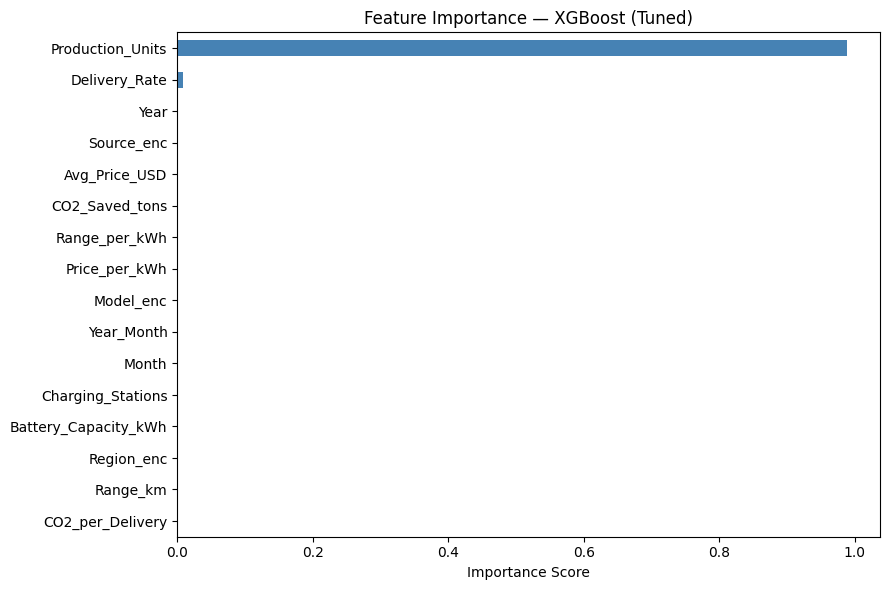

Top 5 Features:
Production_Units    0.987623
Delivery_Rate       0.007852
Year                0.001646
Source_enc          0.001324
Avg_Price_USD       0.000346
dtype: float32


In [13]:
import matplotlib.pyplot as plt

fi = (pd.Series(best_model.feature_importances_, index=FEATURES)
        .sort_values(ascending=True))

fi.plot(kind='barh', figsize=(9, 6), color='steelblue')
plt.title('Feature Importance — XGBoost (Tuned)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 Features:")
print(fi.sort_values(ascending=False).head())

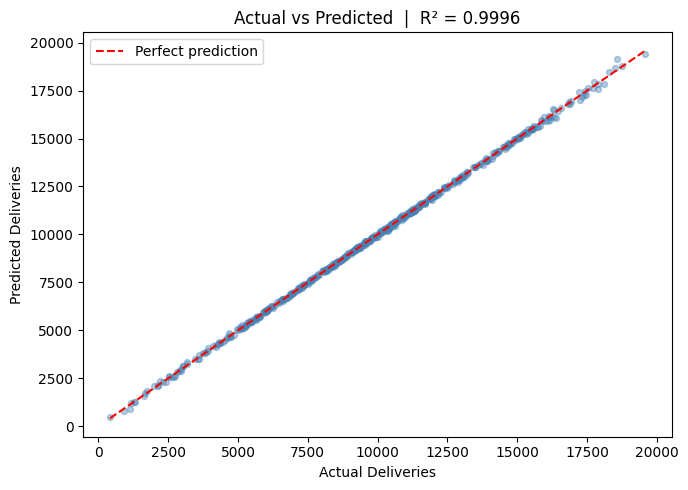

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.4, s=18, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=1.5, label='Perfect prediction')
plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.title(f'Actual vs Predicted  |  R² = {r2:.4f}')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
import joblib

joblib.dump(best_model, '/kaggle/working/tesla_xgb_best_model.pkl')
joblib.dump(scaler,     '/kaggle/working/tesla_scaler.pkl')

print("Saved: tesla_xgb_best_model.pkl")
print("Saved: tesla_scaler.pkl")

Saved: tesla_xgb_best_model.pkl
Saved: tesla_scaler.pkl


In [16]:
import joblib

loaded_model = joblib.load('/kaggle/working/tesla_xgb_best_model.pkl')

new_data = pd.DataFrame([{
    'Year': 2025, 'Month': 6, 'Production_Units': 22000,
    'Avg_Price_USD': 58000, 'Battery_Capacity_kWh': 100,
    'Range_km': 600, 'CO2_Saved_tons': 1400,
    'Charging_Stations': 13000, 'Region_enc': 2,
    'Model_enc': 2, 'Source_enc': 1,
    'Delivery_Rate': 0.91, 'Price_per_kWh': 580,
    'CO2_per_Delivery': 0.064, 'Range_per_kWh': 6.0,
    'Year_Month': 2025 * 12 + 6
}])

prediction = loaded_model.predict(new_data)[0]
print(f"Predicted Deliveries for June 2025: {int(prediction):,}")

Predicted Deliveries for June 2025: 19,875
